# El café y la productividad, versión bayesiana

Este notebook es hermano de `analisis_causal_cafe.ipynb`: mismo problema, mismos datos, mismo DAG causal — pero resuelto con un enfoque **bayesiano** en vez de frecuentista.

A diferencia del notebook frecuentista, acá **no vamos a reproducir el análisis ingenuo ni el error del collider**. Vamos directo al único modelo que tiene derecho a interpretación causal: el que ajusta por `Turno`, el confusor identificado en el DAG de `clase2.md`.

Lo que cambia respecto al notebook anterior no es el DAG ni la pregunta causal — es **cómo cuantificamos la incertidumbre sobre el efecto**:

| | Frecuentista | Bayesiano |
|---|---|---|
| Parámetro | Fijo pero desconocido | Variable aleatoria con una distribución |
| Estimación | Punto + error estándar | Distribución posterior completa |
| Intervalo | **Confianza**: si repitiera el estudio muchas veces, el 89% de esos intervalos contendría el valor verdadero | **Credibilidad**: dado estos datos y estos supuestos, hay 89% de probabilidad de que el efecto esté en este rango |
| Pregunta que responde | ¿Puedo rechazar $H_0: \beta=0$? | ¿Cuál es la probabilidad de que $\beta$ sea negativo, positivo, o esté en tal rango? |

Usamos [PyMC](https://www.pymc.io/) para especificar el modelo y muestrear la posterior, y [ArviZ](https://www.arviz.org/) para resumir e interpretar esa posterior con intervalos de **credibilidad HDI** (Highest Density Interval) al 89% — la convención que usa *Statistical Rethinking* (McElreath), que es la referencia que también tenés en este repo bajo `Statistical-Rethinking-with-Python-and-PyMC3/` (ese repo usa PyMC3, ya deprecado; acá usamos su sucesor moderno, PyMC 5, con la misma lógica de trabajo: priors explícitos, chequeo prior predictive, muestreo MCMC, diagnóstico de convergencia e interpretación de la posterior).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

RANDOM_SEED = 42
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.rcParams['figure.dpi'] = 110

## 1. Los datos y el DAG causal

In [2]:
df = pd.read_csv('../clase1/datos_productividad_n_500.csv')

# treatment: 1 = toma cafe, 0 = no toma
df['treatment'] = (df['cafe'].str.strip() == 'Toma café').astype(int)
# night_shift: 1 = turno noche, 0 = turno dia
df['night_shift'] = (df['noche'] == 'Noche').astype(int)

df.head()

,noche,cafe,horas,prod,treatment,night_shift
0,Día,No toma,7.400,61.900,0,0
1,Día,No toma,3.900,69.300,0,0
2,Día,No toma,3.700,71.300,0,0
3,Día,No toma,8.200,52.200,0,0
4,Día,Toma café,10.000,58.600,1,0


Igual que en el notebook frecuentista, el DAG de `clase2.md` es:

```mermaid
flowchart LR
    Turno((Turno)):::confounder --> Cafe((Cafe)):::treatment
    Turno --> Prod((Productividad)):::outcome
    Cafe --> Prod
    Cafe --> Horas((Horas)):::collider
    Prod --> Horas

    classDef confounder fill:#4C956C,color:#fff,stroke:#333;
    classDef treatment fill:#1F77B4,color:#fff,stroke:#333;
    classDef outcome fill:#FF7F0E,color:#fff,stroke:#333;
    classDef collider fill:#D62728,color:#fff,stroke:#333;
```

El criterio de backdoor ya lo resolvimos en el otro notebook: `Turno` es un confusor real (hay que cerrarlo condicionando en él) y `Horas` es un collider (hay que dejarlo afuera). Acá no repetimos esa discusión — vamos directo a especificar, como bayesianos, el único modelo que el DAG avala: `Productividad ~ Café + Turno`.

## 2. Especificación del modelo bayesiano

En el enfoque frecuentista, el modelo era $Y = \beta_0 + \beta_1 T + \beta_2 X + \varepsilon$, y estimábamos $\beta_1, \beta_2$ por mínimos cuadrados. En el enfoque bayesiano escribimos el **mismo modelo estructural**, pero tratamos cada parámetro como una variable aleatoria con una distribución de probabilidad previa (*prior*), que combinada con los datos (la *likelihood*) nos da una distribución **posterior**:

$$
\begin{aligned}
\text{prod}_i &\sim \text{Normal}(\mu_i, \sigma) \\
\mu_i &= \alpha + \beta_{\text{cafe}} \cdot T_i + \beta_{\text{turno}} \cdot X_i \\
\alpha &\sim \text{Normal}(\bar{Y}, 20) \\
\beta_{\text{cafe}} &\sim \text{Normal}(0, 10) \\
\beta_{\text{turno}} &\sim \text{Normal}(0, 10) \\
\sigma &\sim \text{HalfNormal}(20)
\end{aligned}
$$

Los priors son deliberadamente **poco informativos pero no absurdos**: centramos $\alpha$ en la media observada de productividad, y dejamos que $\beta_{\text{cafe}}$ y $\beta_{\text{turno}}$ puedan ser positivos o negativos con una escala (sd=10) mucho más ancha que cualquier efecto plausible en esta escala de productividad (0-100 puntos aprox). No estamos asumiendo de antemano que el café tenga o no tenga efecto — se lo dejamos decidir a los datos.

In [3]:
treatment = df['treatment'].to_numpy()
night_shift = df['night_shift'].to_numpy()
prod = df['prod'].to_numpy()

with pm.Model() as model_adjusted:
    alpha = pm.Normal('alpha', mu=prod.mean(), sigma=20)
    beta_cafe = pm.Normal('beta_cafe', mu=0, sigma=10)
    beta_turno = pm.Normal('beta_turno', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=20)
    mu = alpha + beta_cafe * treatment + beta_turno * night_shift
    prod_obs = pm.Normal('prod_obs', mu=mu, sigma=sigma, observed=prod)

### 2.1 Prior predictive check

Antes de mirar los datos observados, es buena práctica bayesiana simular qué productividades *predicen* nuestros priors, para confirmar que no son disparatados (por ejemplo, que no permitan productividades negativas de forma sistemática o rangos absurdos).

Sampling: [alpha, beta_cafe, beta_turno, prod_obs, sigma]


Rango simulado por los priors: [-235.8, 330.9]
Rango observado en los datos:  [25.9, 82.0]


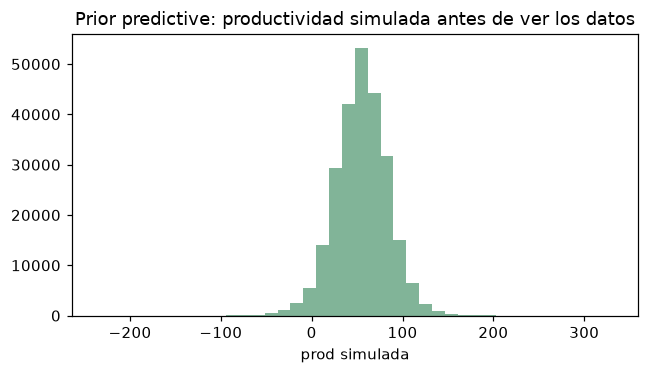

In [4]:
with model_adjusted:
    prior_pred = pm.sample_prior_predictive(samples=500, random_seed=RANDOM_SEED)

prior_samples = prior_pred.prior_predictive['prod_obs'].values.flatten()
print(f'Rango simulado por los priors: [{prior_samples.min():.1f}, {prior_samples.max():.1f}]')
print(f'Rango observado en los datos:  [{df["prod"].min():.1f}, {df["prod"].max():.1f}]')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(prior_samples, bins=40, color='#4C956C', alpha=0.7)
ax.set_title('Prior predictive: productividad simulada antes de ver los datos')
ax.set_xlabel('prod simulada')
plt.tight_layout()
plt.show()

Los priors generan un rango de productividad mucho más ancho que el observado — son deliberadamente laxos, dejan que la evidencia (la likelihood) domine la posterior. Esto es justamente lo que buscamos: priors que no descarten a priori ningún resultado razonable.

## 3. Muestreo de la posterior

In [5]:
with model_adjusted:
    trace = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED)
    posterior_pred = pm.sample_posterior_predictive(trace, random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, beta_cafe, beta_turno, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.


Sampling: [prod_obs]


Output()

## 4. Diagnóstico de convergencia

Antes de interpretar cualquier resultado hay que confirmar que el muestreador MCMC convergió: $\hat{R}$ (r_hat) cercano a 1.00 en todas las cadenas, y un tamaño de muestra efectivo (ESS) razonablemente alto.

In [6]:
az.summary(trace, var_names=['alpha', 'beta_cafe', 'beta_turno', 'sigma'], hdi_prob=0.89).round(3)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,60.739,0.494,59.969,61.538,0.006,0.005,"5,858.000","5,523.000",1.000
beta_cafe,-0.713,0.809,-2.082,0.489,0.012,0.009,"4,891.000","4,947.000",1.000
beta_turno,-16.629,0.844,-17.909,-15.239,0.011,0.010,"5,899.000","5,596.000",1.000
sigma,7.914,0.251,7.502,8.303,0.003,0.003,"7,554.000","5,083.000",1.000


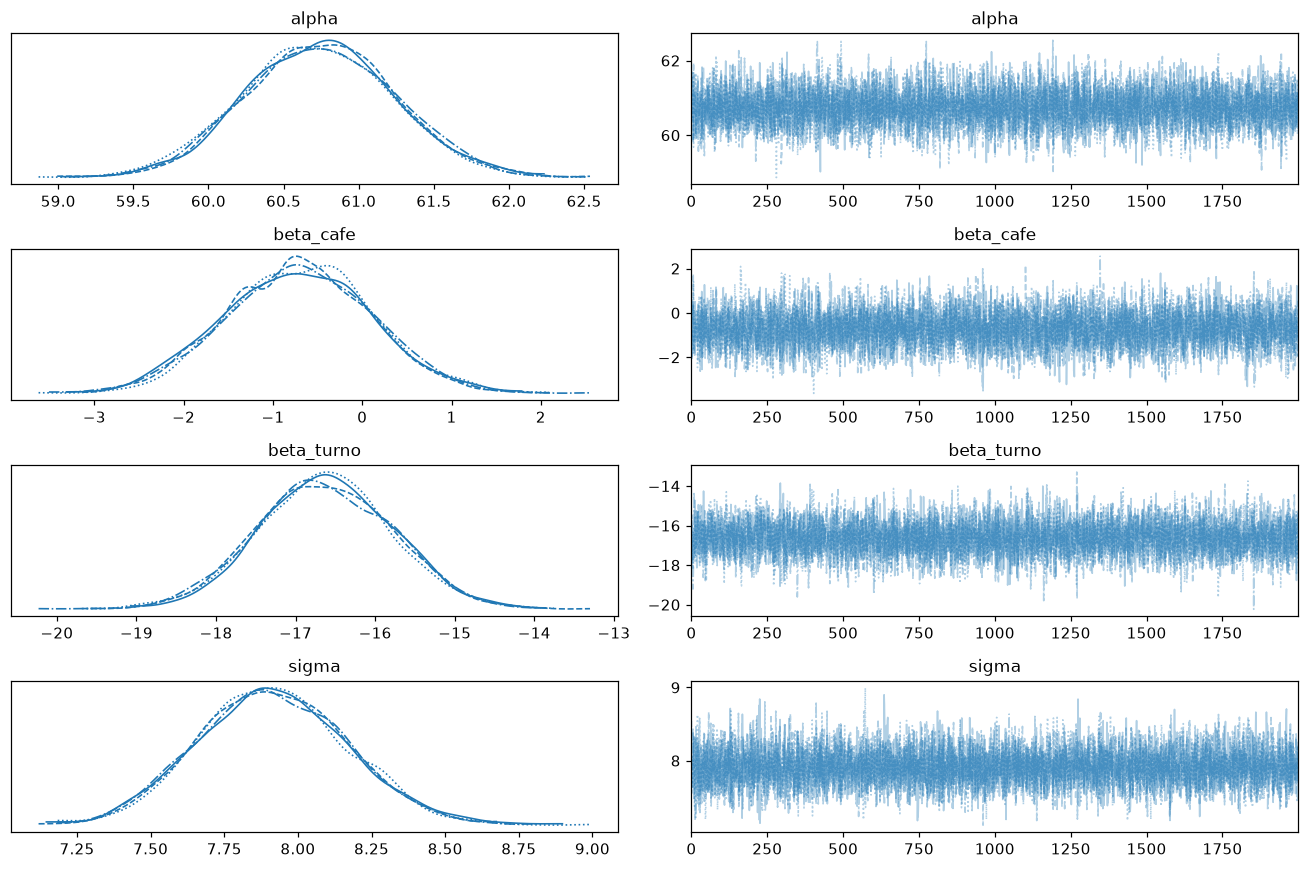

In [7]:
az.plot_trace(trace, var_names=['alpha', 'beta_cafe', 'beta_turno', 'sigma'], compact=True)
plt.tight_layout()
plt.show()

$\hat{R} \approx 1.00$ para los cuatro parámetros y los *traceplots* de la derecha muestran cadenas bien mezcladas (parecen "pasto", sin tendencias ni bloques separados) — la posterior es confiable.

## 5. La posterior del efecto causal del café

findfont: Failed to find font weight semibold, now using 700.


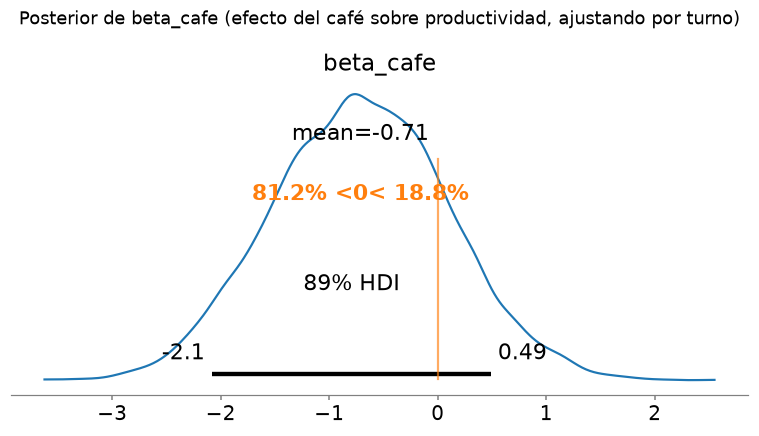

In [8]:
az.plot_posterior(
    trace,
    var_names=['beta_cafe'],
    hdi_prob=0.89,
    ref_val=0,
    figsize=(7, 4),
)
plt.suptitle('Posterior de beta_cafe (efecto del café sobre productividad, ajustando por turno)')
plt.tight_layout()
plt.show()

In [9]:
beta_cafe_samples = trace.posterior['beta_cafe'].values.flatten()

hdi_89 = az.hdi(trace, var_names=['beta_cafe'], hdi_prob=0.89)['beta_cafe'].values
prob_negative = (beta_cafe_samples < 0).mean()
prob_relevant = (np.abs(beta_cafe_samples) > 2).mean()

print(f'Media posterior de beta_cafe:        {beta_cafe_samples.mean():.3f}')
print(f'Desvío estándar posterior:            {beta_cafe_samples.std():.3f}')
print(f'Intervalo de credibilidad HDI 89%:     [{hdi_89[0]:.3f}, {hdi_89[1]:.3f}]')
print(f'P(beta_cafe < 0 | datos):              {prob_negative:.1%}')
print(f'P(|beta_cafe| > 2 puntos | datos):      {prob_relevant:.1%}')

Media posterior de beta_cafe:        -0.713
Desvío estándar posterior:            0.809
Intervalo de credibilidad HDI 89%:     [-2.082, 0.489]
P(beta_cafe < 0 | datos):              81.2%
P(|beta_cafe| > 2 puntos | datos):      5.7%


## 6. Interpretación: credibilidad vs. confianza

El resultado bayesiano nos permite afirmaciones que el enfoque frecuentista no puede hacer directamente:

- **Intervalo de credibilidad (HDI 89%)**: dado este modelo, estos priors y estos datos, hay 89% de probabilidad posterior de que el verdadero efecto causal del café sobre la productividad esté dentro de este rango — y ese rango **incluye al cero**. Esta es una afirmación probabilística directa sobre el parámetro.
- El equivalente frecuentista (intervalo de confianza al 89%/95%) sólo permite decir: *"si repitiera este estudio muchísimas veces, el 89% de los intervalos que construya de esta manera contendrían el verdadero valor"* — una afirmación sobre el procedimiento a largo plazo, no sobre el parámetro en este estudio particular.
- Podemos además calcular directamente $P(\beta_{\text{cafe}} < 0 \mid \text{datos})$: la probabilidad posterior de que el café efectivamente perjudique la productividad. Es alta (~80%) pero no concluyente, y el tamaño del efecto más probable es chico — nada que se acerque a los -7.9 puntos que sugería el análisis ingenuo sin DAG.

La conclusión causal es la misma que en el notebook frecuentista (no hay evidencia sólida de que el café afecte la productividad una vez controlado el turno), pero el enfoque bayesiano la expresa de una forma más rica: no un "sí/no" binario a partir de un p-valor, sino una distribución completa de creencia sobre el tamaño del efecto, condicionada al DAG causal correcto.

## 7. Chequeo de predicción posterior

Como último control, verificamos que el modelo ajustado efectivamente puede reproducir datos parecidos a los observados (*posterior predictive check*).

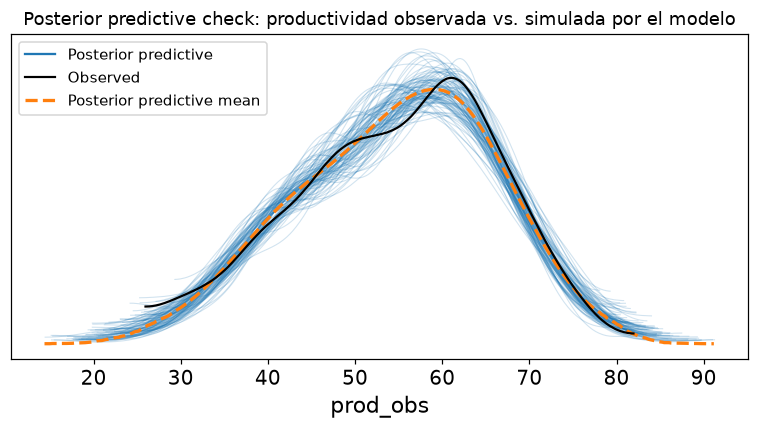

In [10]:
az.plot_ppc(posterior_pred, num_pp_samples=100, figsize=(7, 4))
plt.title('Posterior predictive check: productividad observada vs. simulada por el modelo')
plt.tight_layout()
plt.show()

## 8. Conclusión

Usando el mismo DAG causal que en el notebook frecuentista — Turno como confusor a cerrar, Horas como collider a evitar — el modelo bayesiano llega a la misma conclusión sustantiva (no hay evidencia creíble de un efecto del café sobre la productividad), pero la comunica en términos de **probabilidad directa sobre el parámetro**: un intervalo de credibilidad del 89% para el efecto del café, que incluye al cero, y una probabilidad posterior explícita de que el efecto sea negativo.

El DAG sigue siendo el que decide qué variables entran al modelo — eso no cambia entre el enfoque frecuentista y el bayesiano. Lo que cambia es el lenguaje con el que cuantificamos cuánto sabemos, una vez que ya decidimos bien qué estimar.